In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import mapclassify
import ghslpy
from shapely import wkt

In [2]:
# Define study area (Lagos, Nigeria)
buf = 60_000
# p = "POINT(3.3642891130747983 6.482301819593587)" # Lagos, Nigeria
# p = "POINT(8.51259507981301 12.002657077147319)" # Kano, Nigeria
p = "POINT(5.623935754478583 6.338754647182569)" # Benin City, Nigeria
point = gpd.GeoDataFrame([wkt.loads(p)], columns=["geometry"], crs=4326)
buffered = point.copy()
buffered["geometry"] = buffered.geometry.to_crs(3857).buffer(buf).to_crs(4326)

In [3]:
# Download GHSL data

# epochs = [1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]
# epochs = [1975, 2000, 2020, 2025]
epochs = [2025]

data = ghslpy.download(
    products=["GHS-POP", "GHS-BUILT-S"],
    epoch=epochs,
    resolution="1000m",
    region=buffered,
)

print("Data downloaded successfully!")

Data downloaded successfully!


In [44]:
variable_labels = {
    'GHS_POP': 'Population',
    'GHS_BUILT': 'Built-Up Surface Area (m2)'
}

In [45]:
def plot_variable_date(
    data,
    variable,
    date,
    qbreaks=None,
    scheme=None,
    title=None,
    threshold=0,
    cmap=None,
    extent=None,
    export_path=False
):
    variable_labels = {
        'GHS_POP': 'Population',
        'GHS_BUILT': 'Built-Up Surface Area (m2)'
    }

    if cmap:
        cmap=cmap
    else:
        if variable == "GHS_POP":
            cmap = 'Purples'
        elif variable == "GHS_BUILT":
            cmap = 'Reds'
        else:
            cmap = 'viridis'

    vectors = ghslpy.vectorize(data[variable].to_dataset(name=variable).sel(time=date))
    if extent:
        vectors = vectors.clip(extent)
    values = vectors[vectors[variable]>=threshold][variable].dropna()
    if not scheme:
        if not qbreaks:
            raise "You have to specify qbreaks if not specifying scheme"
        scheme = mapclassify.Quantiles(values, k=qbreaks)

    def format_label(value):
        """Format a single number according to your rules."""
        if value >= 100000:
            # zero decimals, e.g., 300K
            return f"{value/1000:.0f}K"  
        elif value >= 1000:
            if value % 1000 == 0:
                # exact multiple of 1000 → no decimal
                return f"{value/1000:.0f}K"
            else:
                # one decimal
                return f"{value/1000:.1f}K"
        else:
            return str(int(value))
    
    # Build formatted labels for legend
    labels = []
    lower = 0  # start from 0 for the first bin
    for upper in scheme.bins:
        labels.append(f"{format_label(lower)} – {format_label(upper)}")
        lower = upper

    
    legend_kwds={
        "title": variable_labels[variable],
        "loc": "lower center",
        "bbox_to_anchor": (1.2, 0.5),
        "fontsize": 8,
        "labels": labels,   # pass your custom labels here
        "frameon": False
    }
    # Natural Earth 10m scale URLs from GitHub
    rivers_url = "https://github.com/nvkelso/natural-earth-vector/raw/master/10m_physical/ne_10m_rivers_lake_centerlines.shp"
    oceans_url = "https://github.com/nvkelso/natural-earth-vector/raw/master/10m_physical/ne_10m_ocean.shp"
    lakes_url = "https://github.com/nvkelso/natural-earth-vector/raw/master/10m_physical/ne_10m_lakes.shp"
    
    # Load lakes
    rivers = gpd.read_file(rivers_url).clip(vectors.envelope.union_all())
    
    # Load oceans
    oceans = gpd.read_file(oceans_url).clip(vectors[vectors[variable]==0].union_all())
    
    # Load lakes
    lakes = gpd.read_file(lakes_url).clip(vectors.envelope.union_all())
    
    fig, ax = plt.subplots(1, 1, dpi=300)
    vectors.to_crs(3857).plot(
        variable,
        ax=ax,
        cmap=cmap,
        scheme="UserDefined",
        classification_kwds={"bins": scheme.bins},
        legend=True,
        legend_kwds=legend_kwds
    )
    
    water_color='lightblue'
    if len(rivers)!=0:
        rivers.to_crs(3857).plot(ax=ax, lw=0.5, color=water_color)
    if len(oceans)!=0:
        oceans.to_crs(3857).plot(ax=ax, color=water_color)
    if len(lakes)!=0:
        lakes.to_crs(3857).plot(ax=ax, color=water_color)

    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{variable_labels[variable]}\n{date}")

    ax.axis('off')
    plt.tight_layout()
    if export_path:
        assert isinstance(export_path, str), "'export_path' has to be a string"
        plt.savefig(export_path)

    plt.show()
    return fig, ax

In [46]:
extent = wkt.loads('POLYGON((2.8388 7.1335, 4.0805 7.1335, 4.0805 6.3569, 2.8388 6.3569, 2.8388 7.1335))')

In [47]:
built25 = data.GHS_BUILT.sel(time='2025-01-01')
pop25 = data.GHS_POP.sel(time='2025-01-01')

In [48]:
built_bins = [
    1000, 10000, 50000, 100000, 500000, 800000
]

pop_bins = [
    100, 500, 1000, 10000, 50000, 110000
]

In [49]:
built_scheme=mapclassify.UserDefined(built25.values.flatten(), bins=built_bins)
pop_scheme=mapclassify.UserDefined(pop25.values.flatten(), bins=pop_bins)

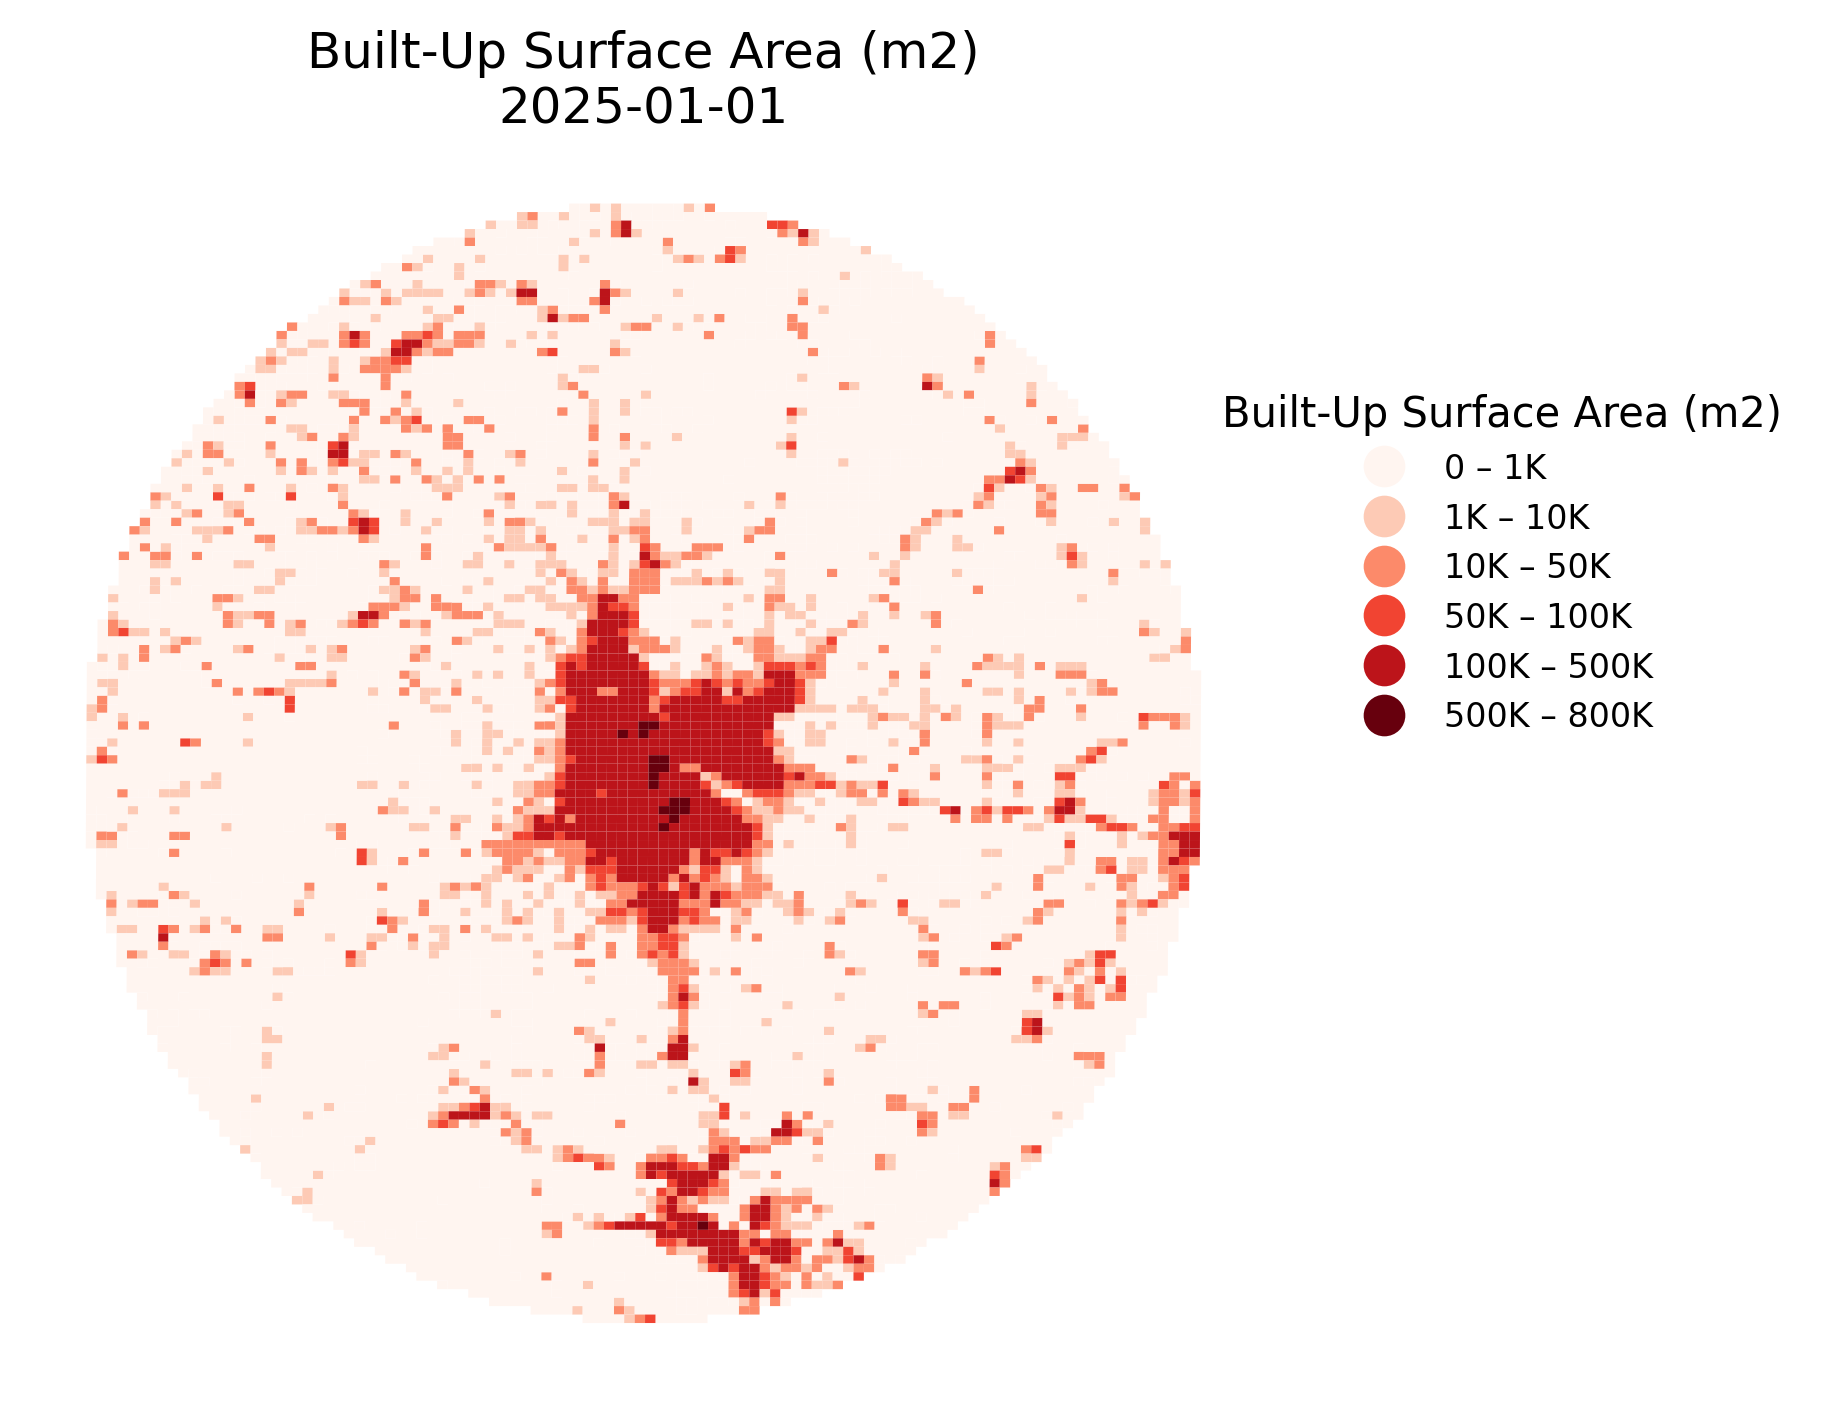

In [50]:
fig, ax = plot_variable_date(
    data,
    'GHS_BUILT',
    '2025-01-01',
    scheme=built_scheme,
    #extent=extent
)

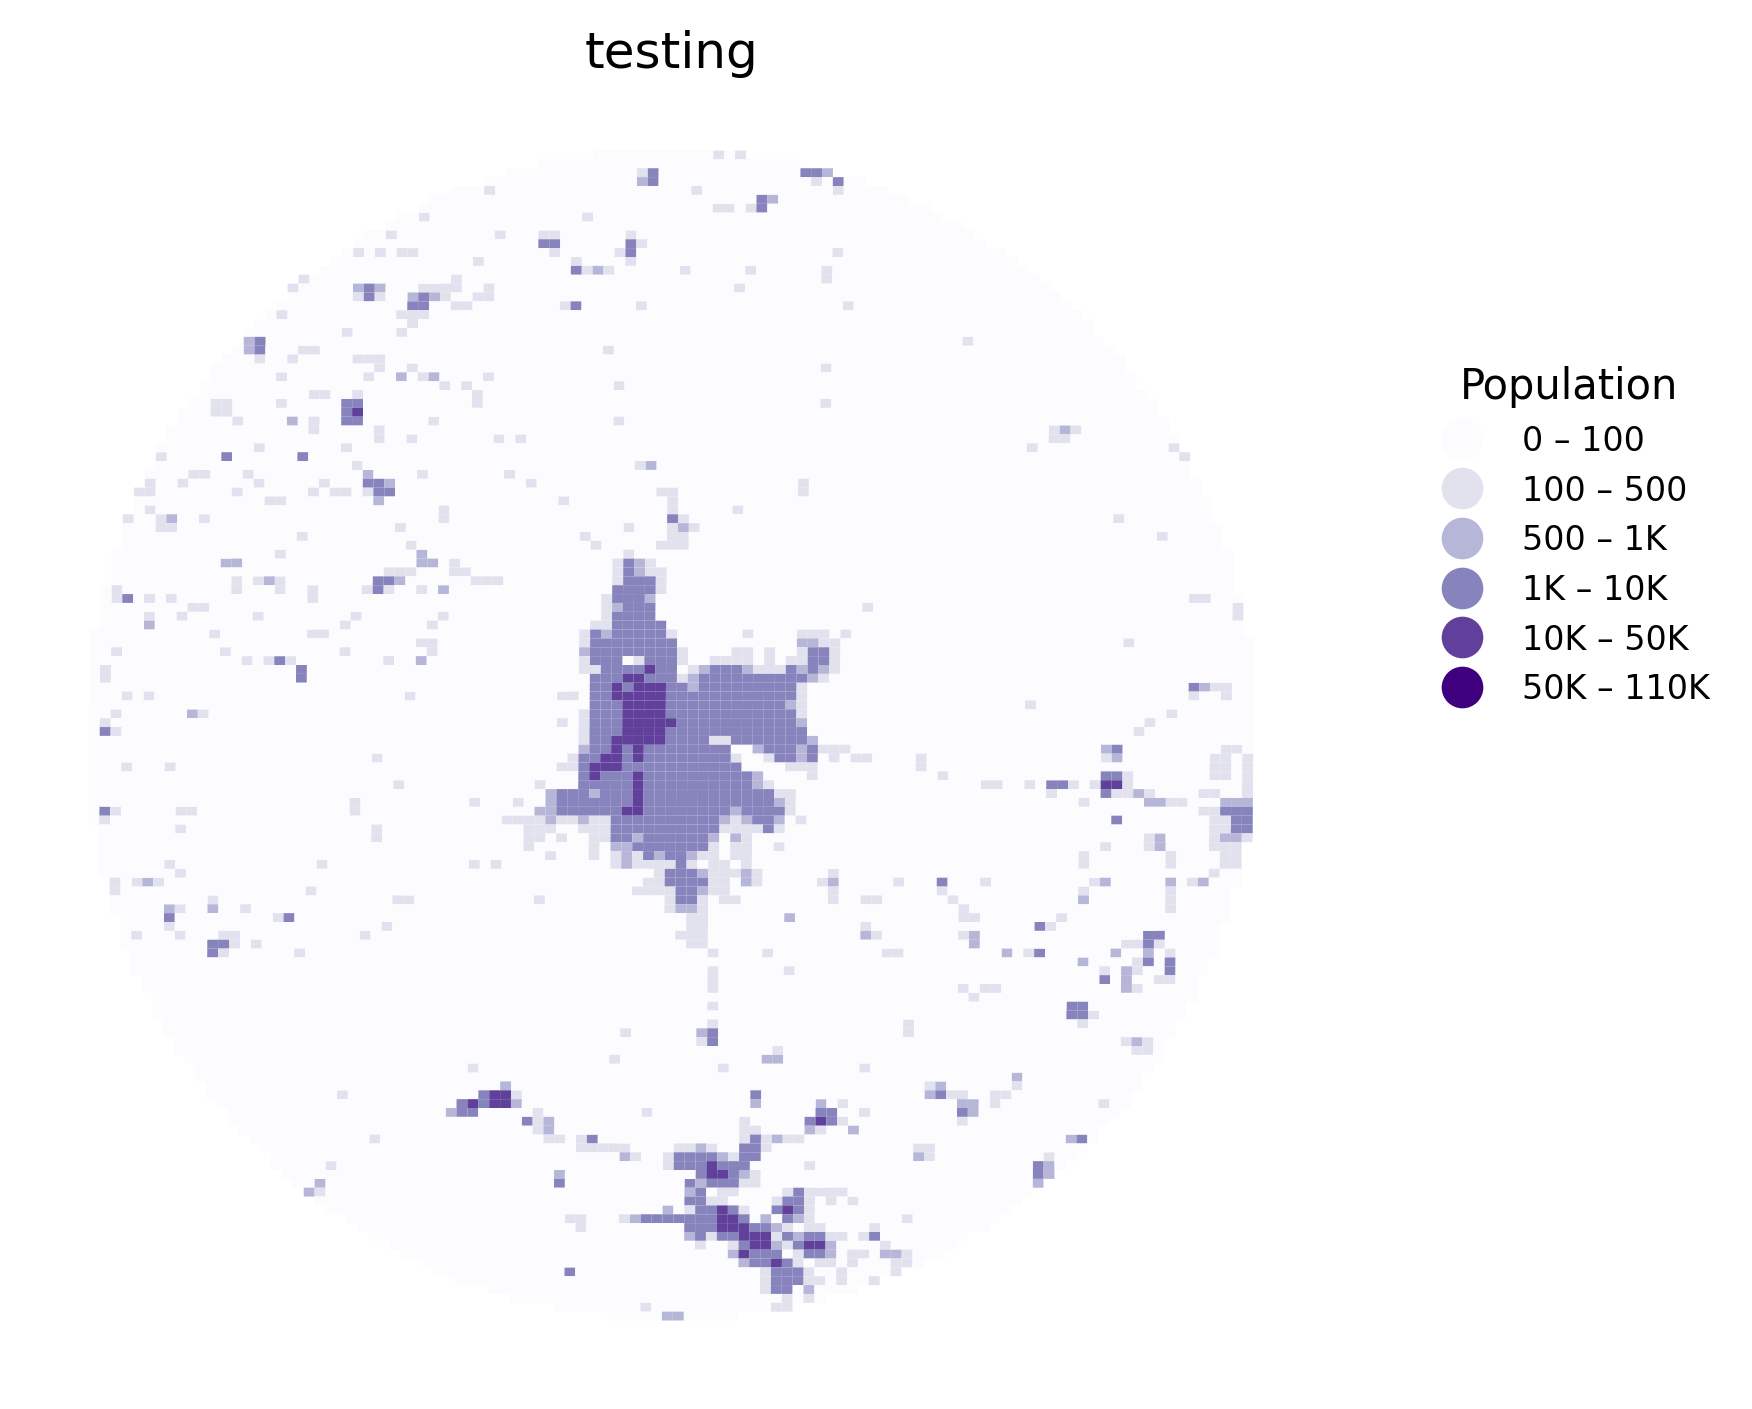

(<Figure size 1920x1440 with 1 Axes>, <Axes: title={'center': 'testing'}>)

In [51]:
plot_variable_date(
    data,
    'GHS_POP',
    '2025-01-01',
    title='testing',
    scheme=pop_scheme,
    #extent=extent
)

In [52]:
dates = [f"{epoch}-01-01" for epoch in epochs]

In [53]:
import imageio.v2 as imageio
import numpy as np

def create_gif(
    data,
    variable,
    scheme,
    export_name,
    fps=1.0,
    threshold=0,
    title=None,
    extent=None,
):
    dates = data.time.values
    frames = []
    for date in dates:
        fig, ax = plot_variable_date(
            data,
            variable,
            date,
            scheme=scheme,
            threshold = threshold,
            extent=extent
        )
        fname = f"frames/frame_{date.replace('-','')}.png"
        fig.savefig(fname)
        plt.close(fig)  # close to save memory
        frames.append(fname)
    
    # Create GIF
    images = [imageio.imread(fname) for fname in frames]
    imageio.mimsave(export_name, images, fps=fps)

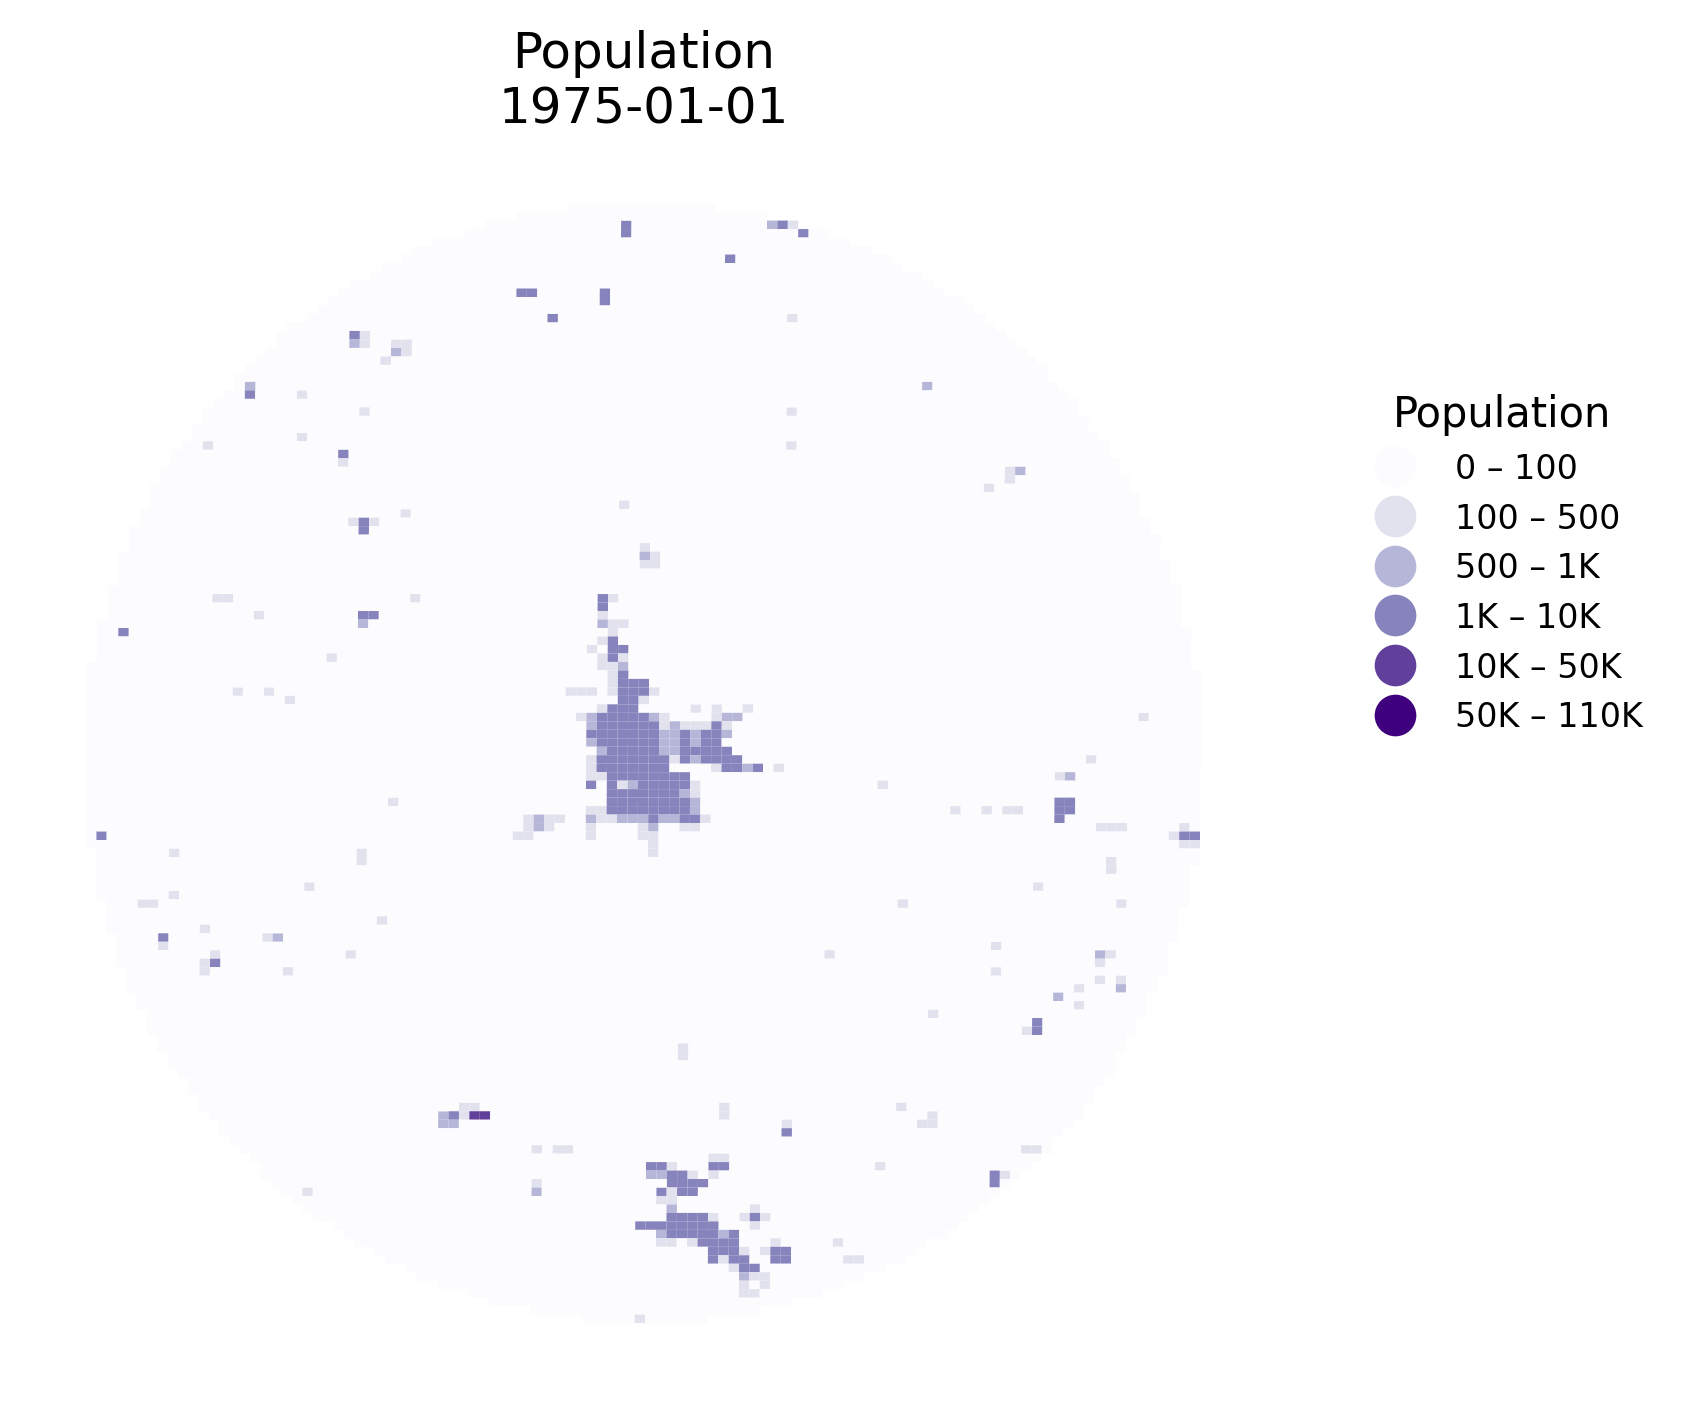

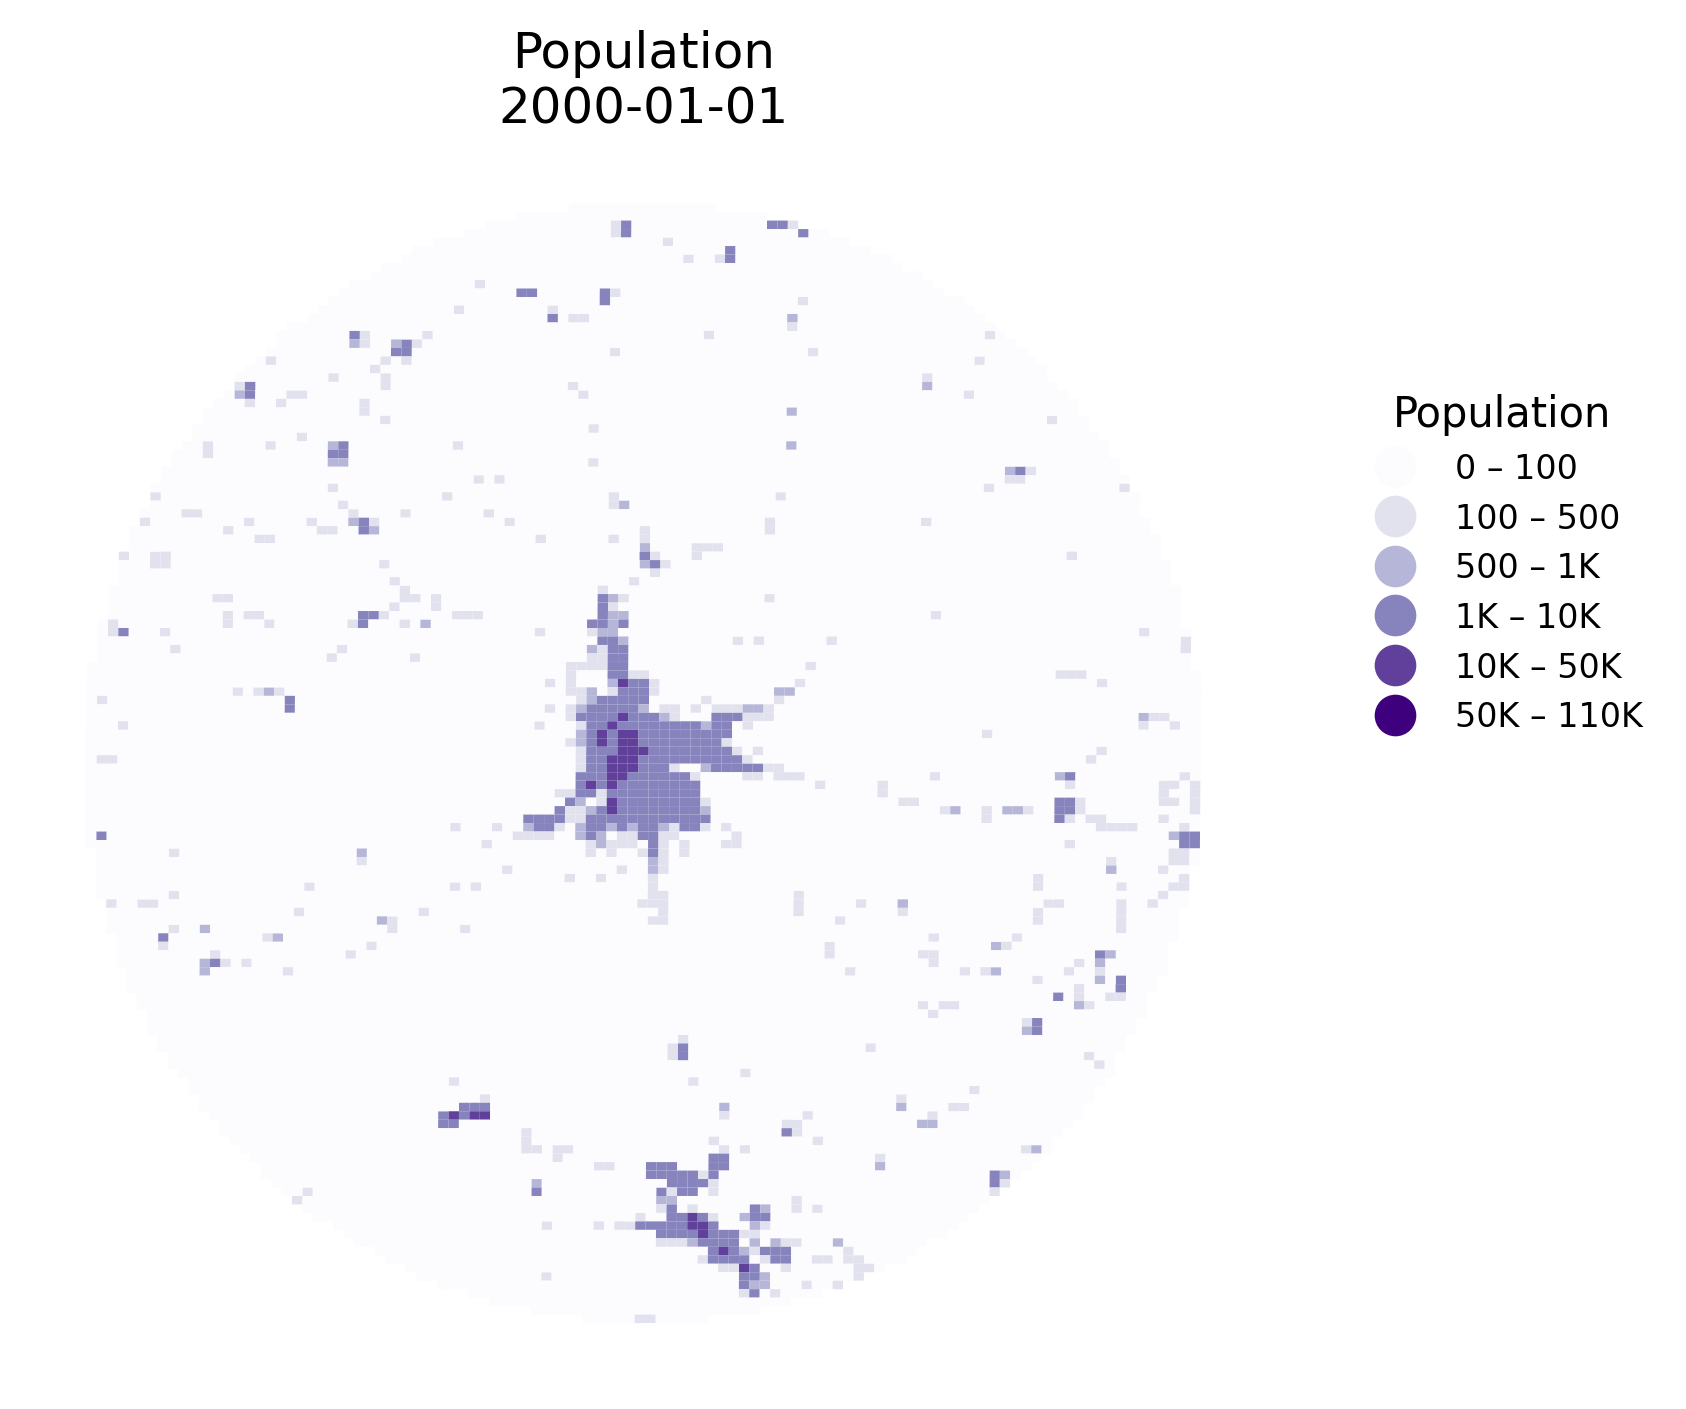

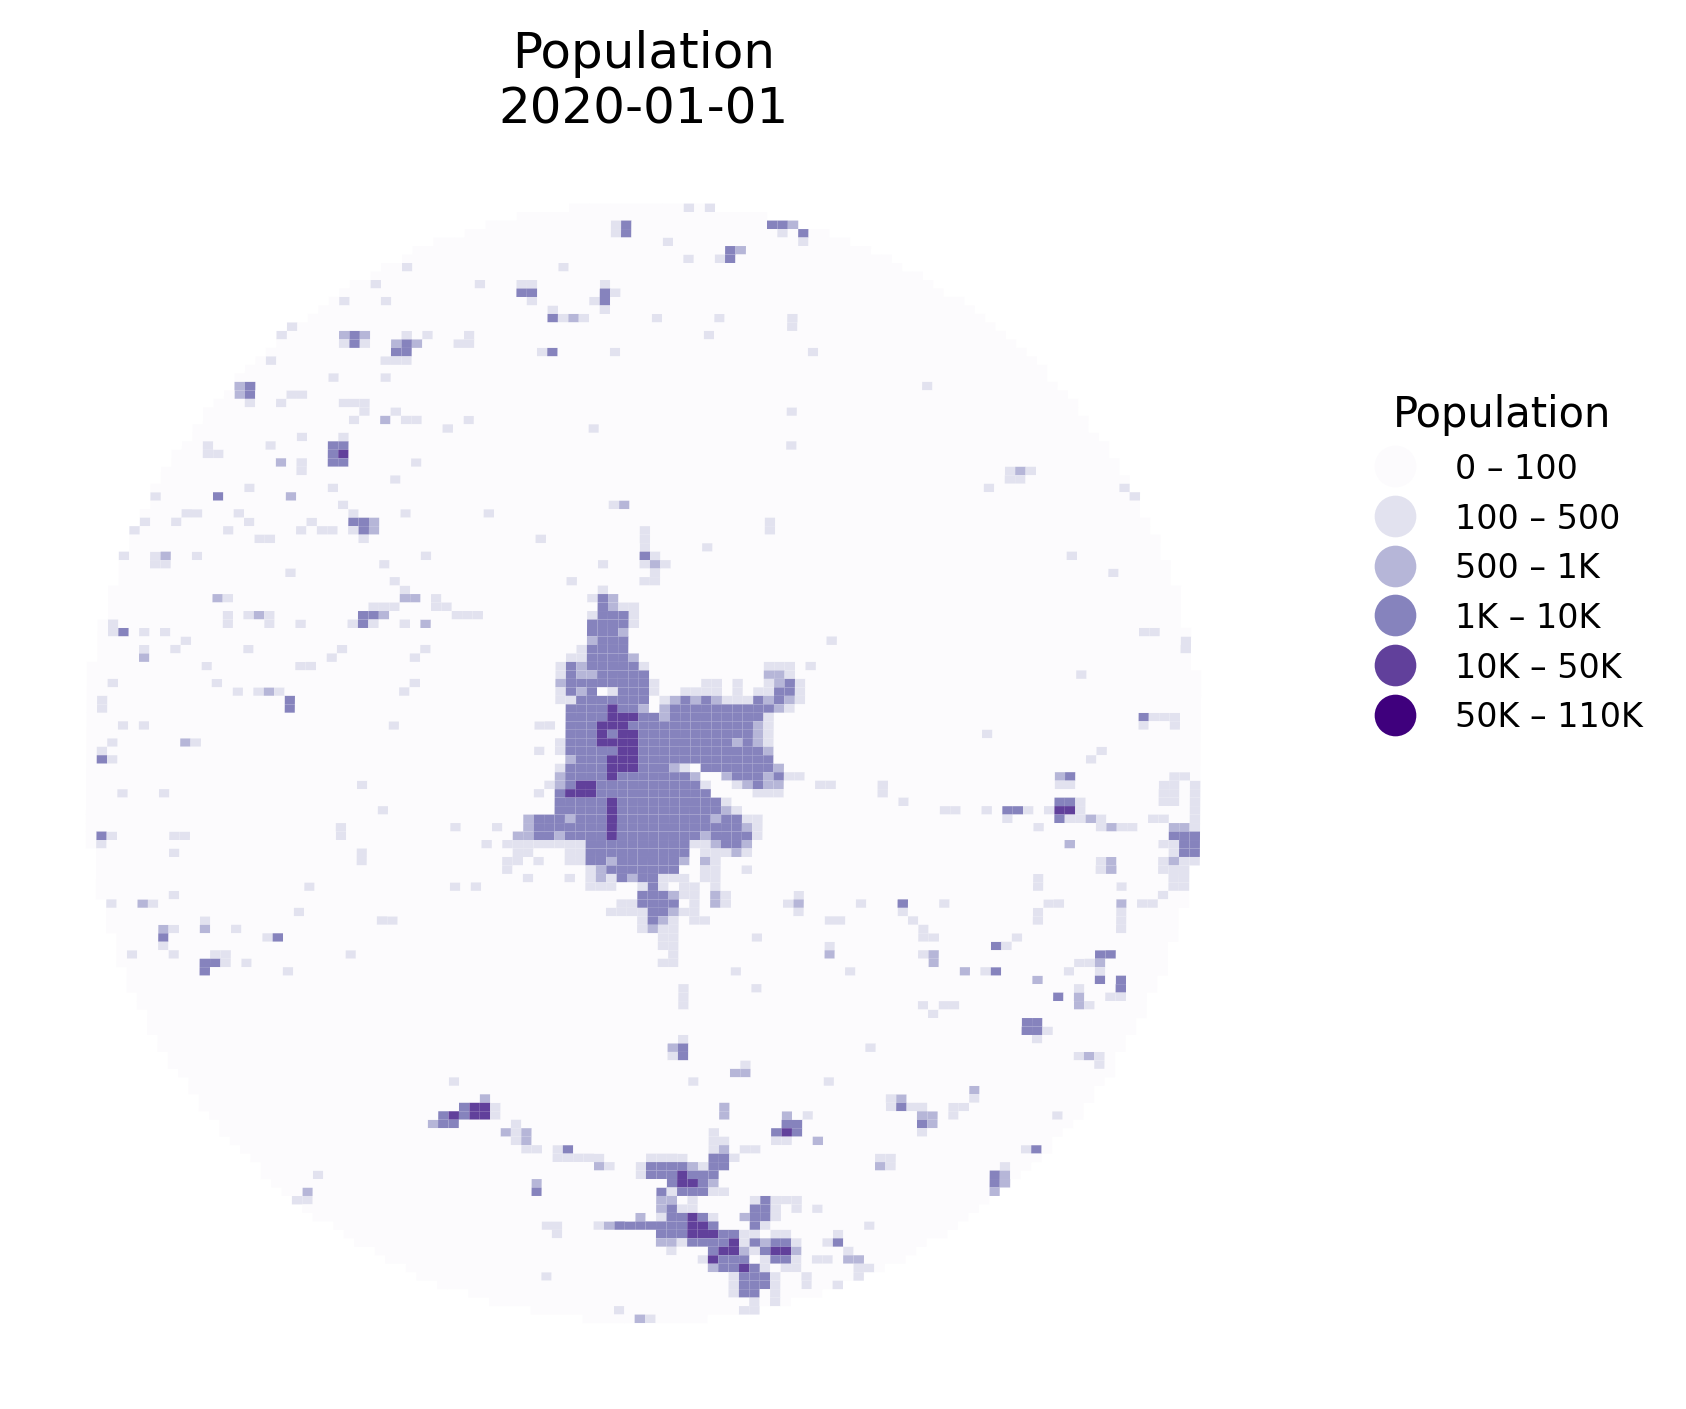

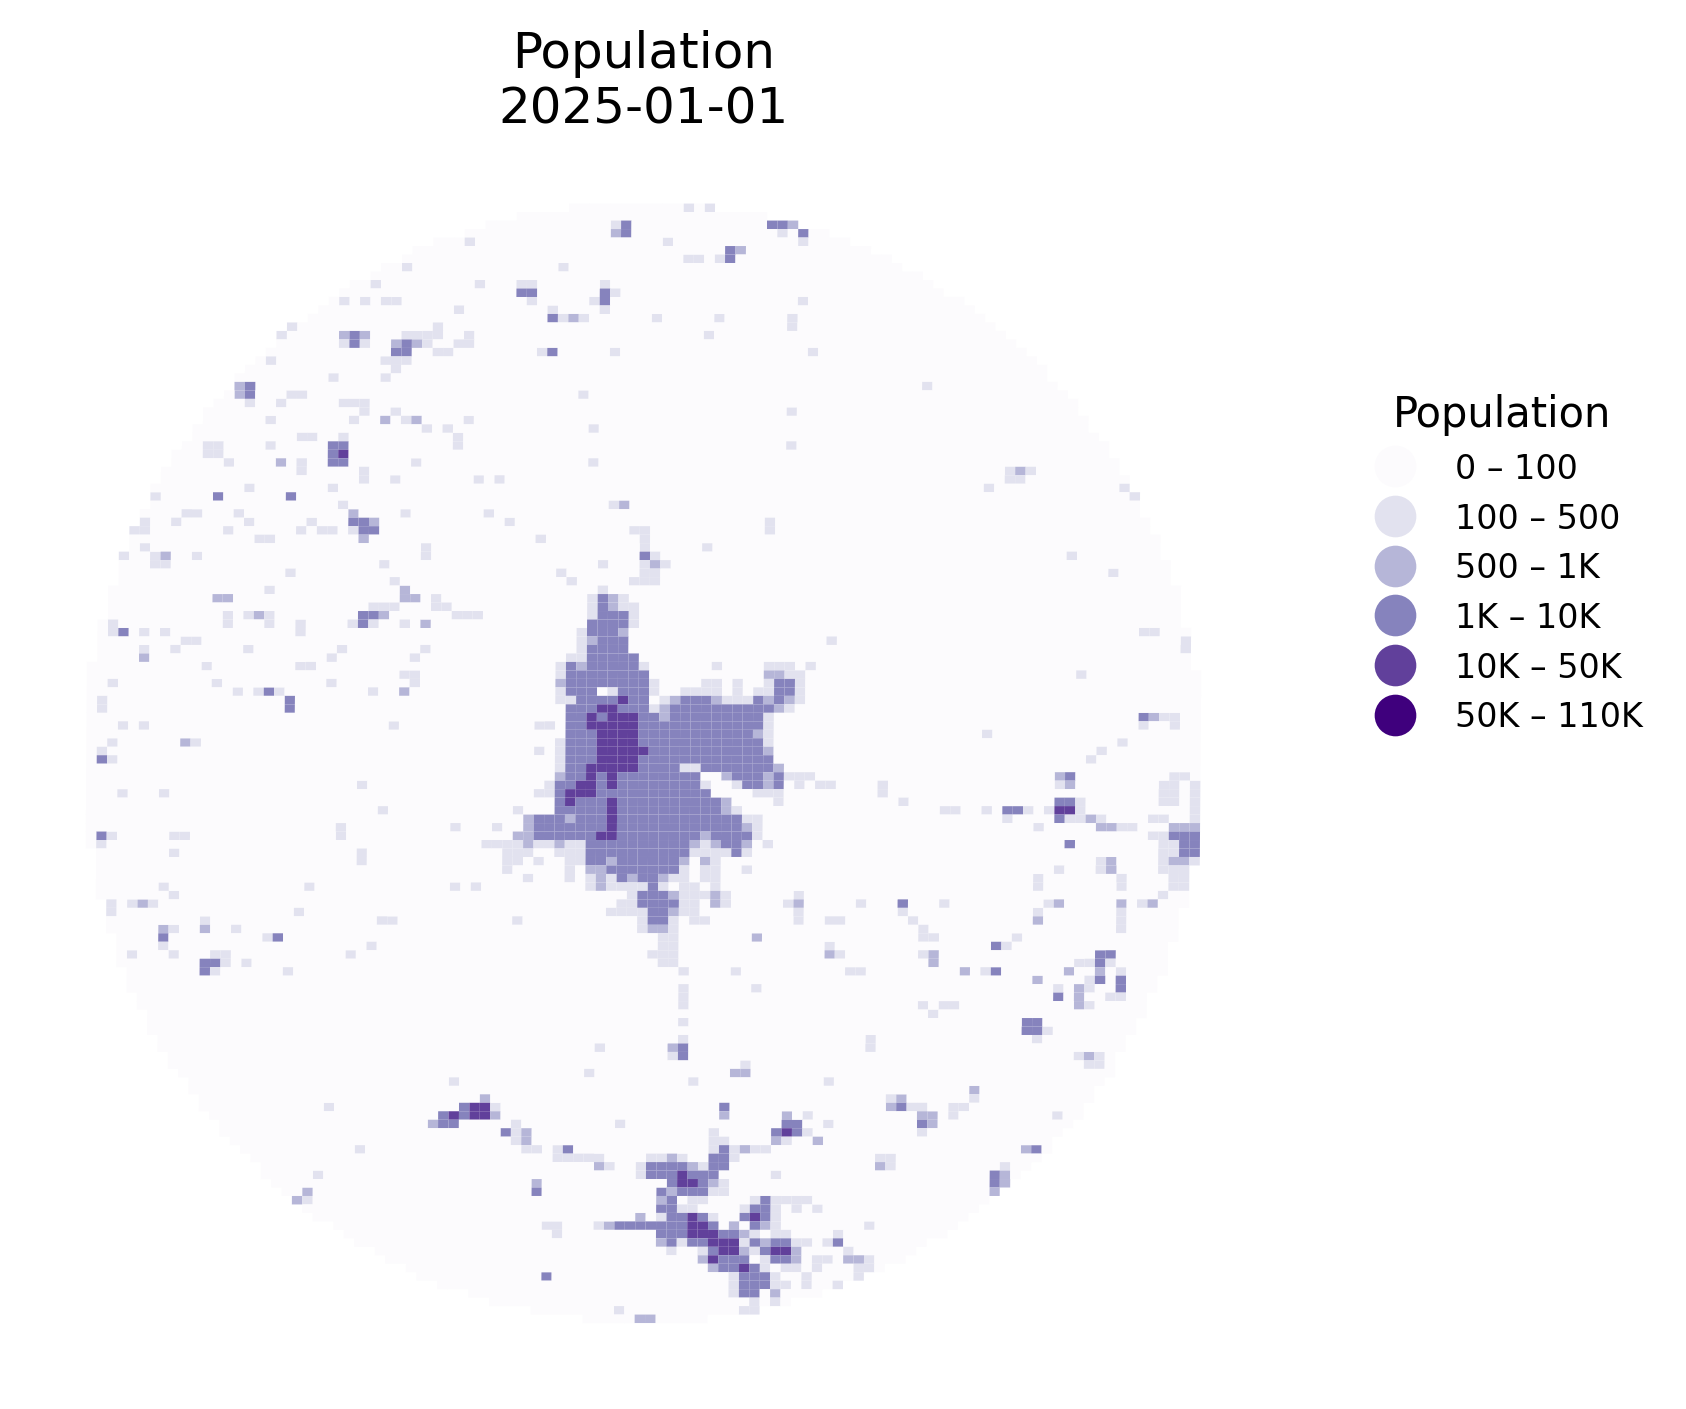

In [54]:
create_gif(
    data=data,
    variable='GHS_POP',
    scheme=pop_scheme,
    fps=1.0,
    export_name="frames/ghs_pop.gif"
)

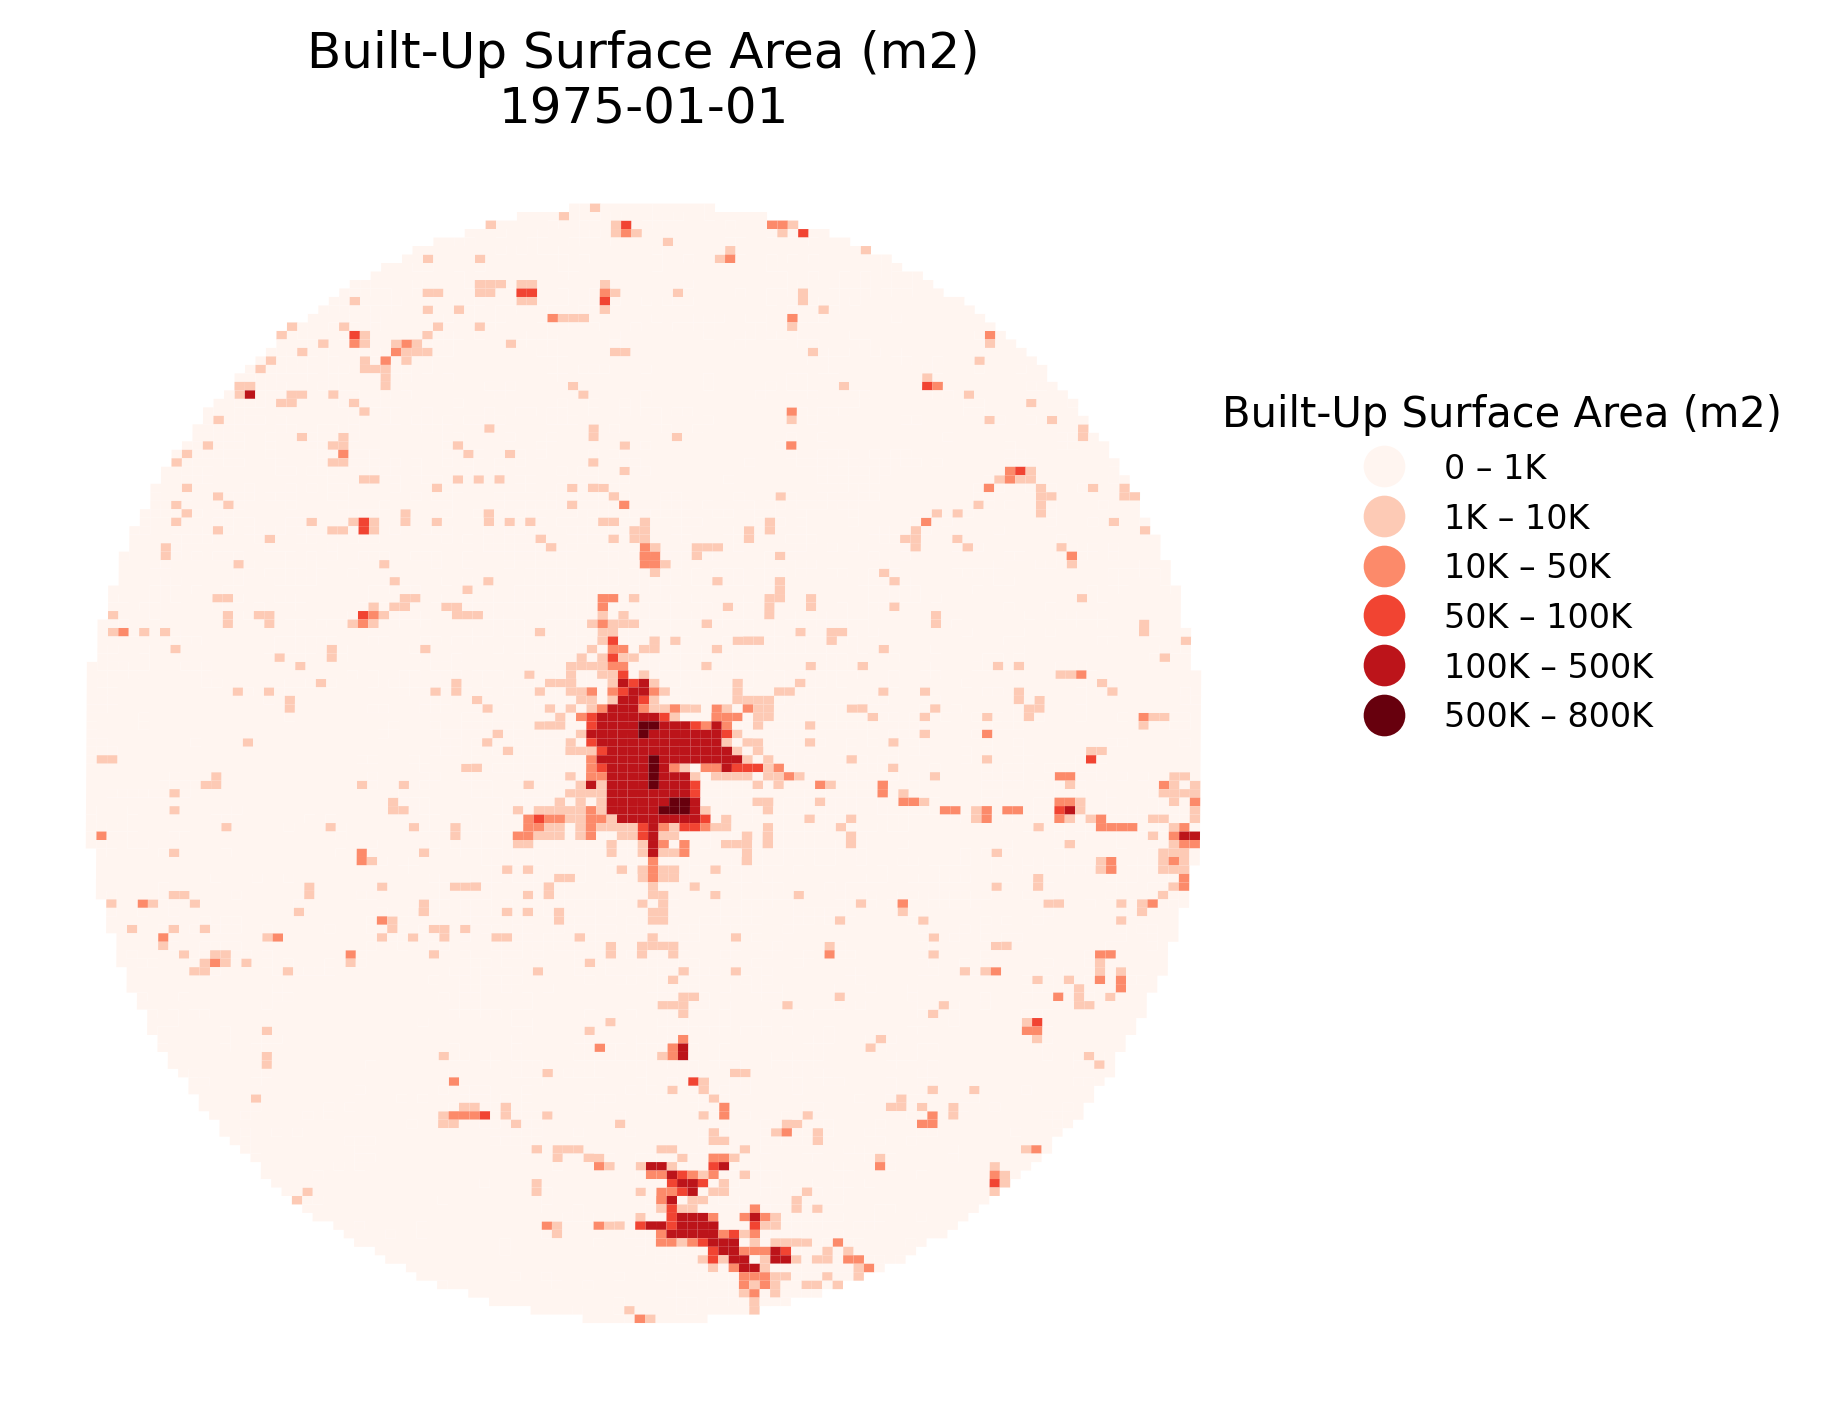

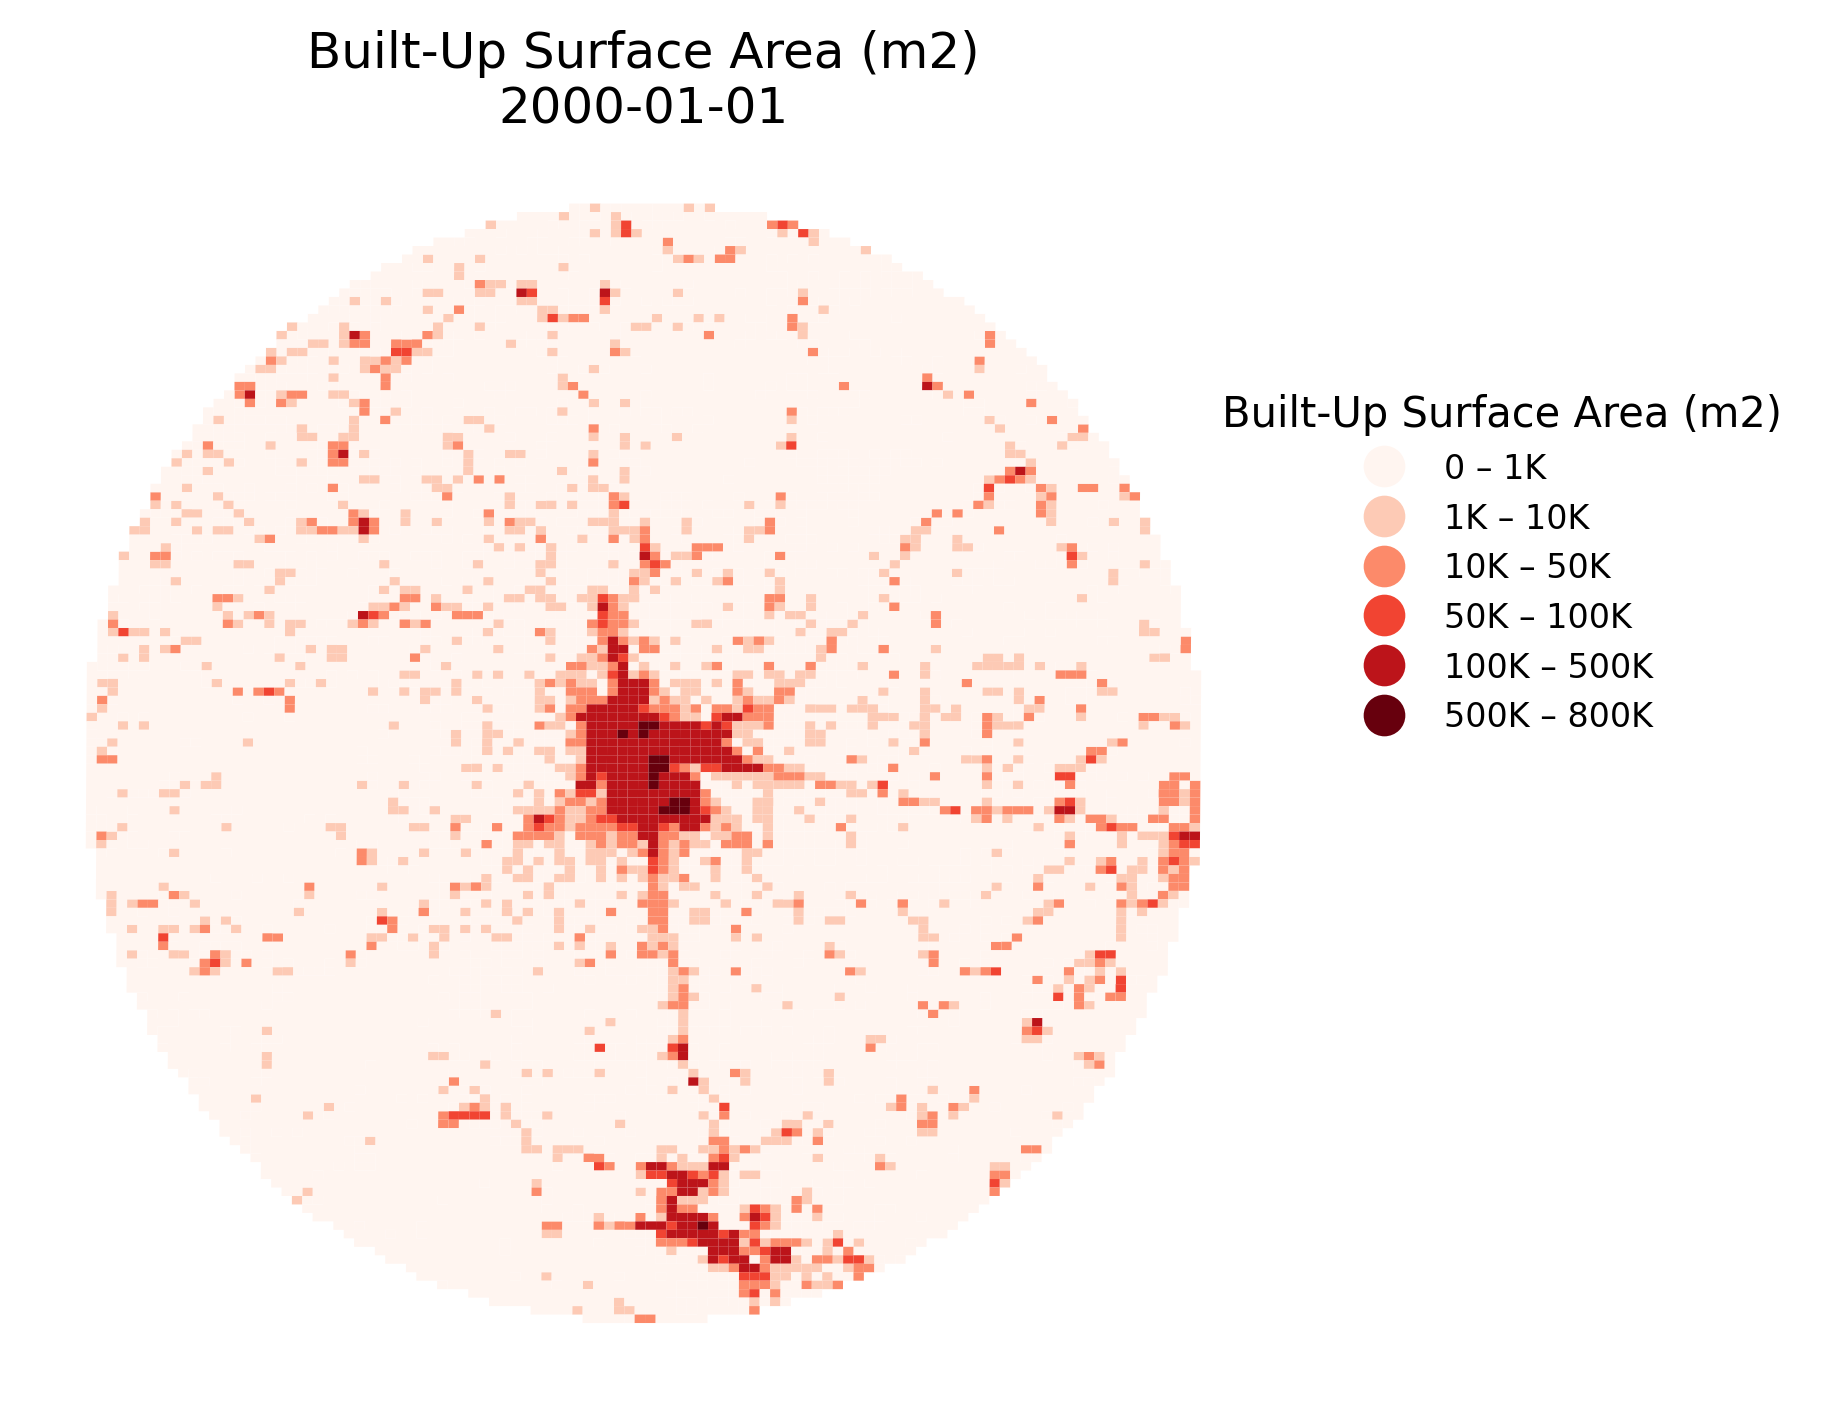

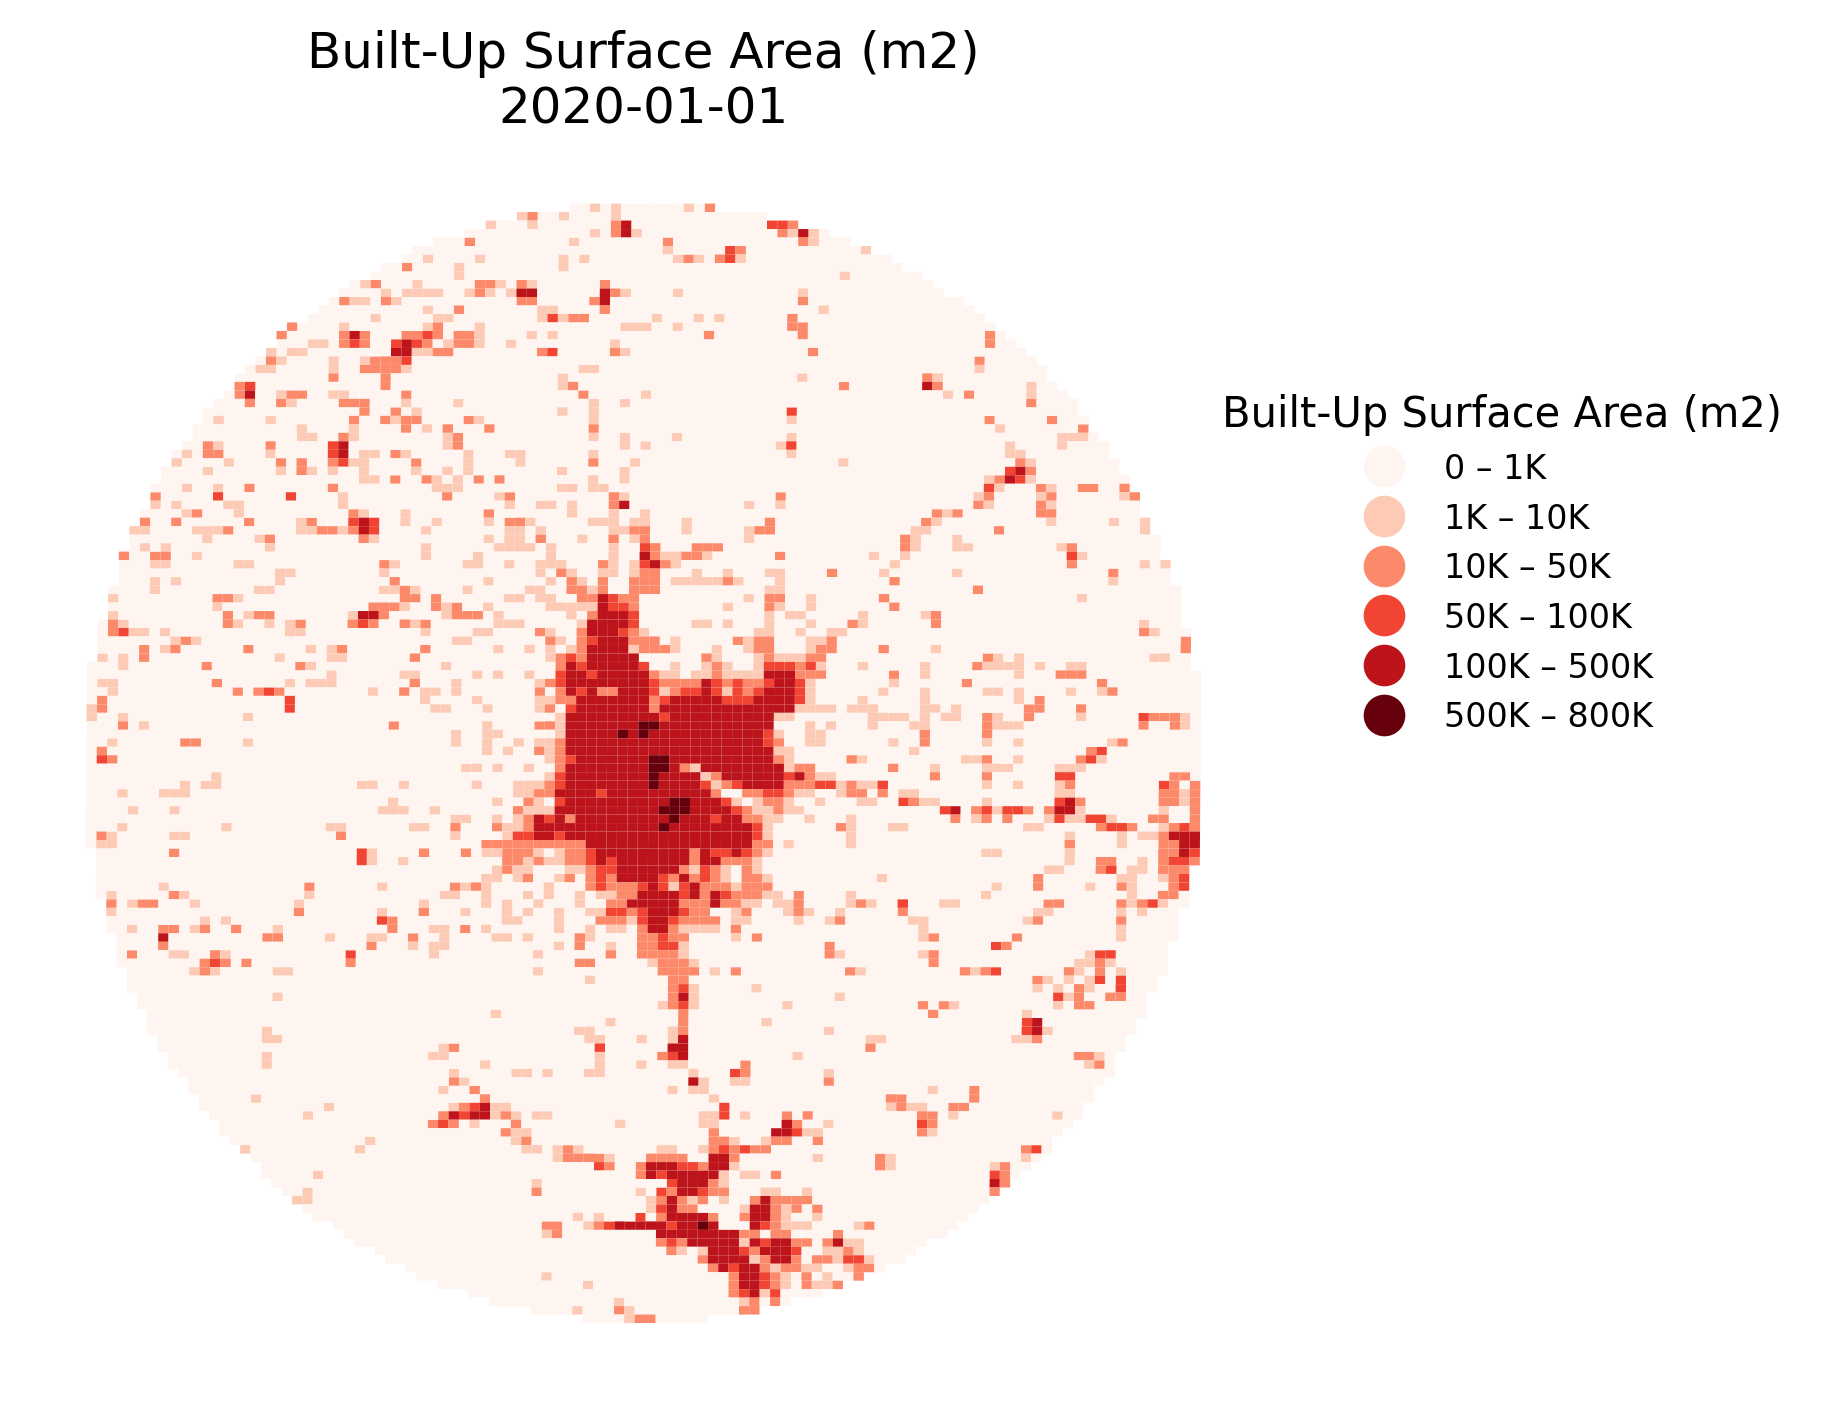

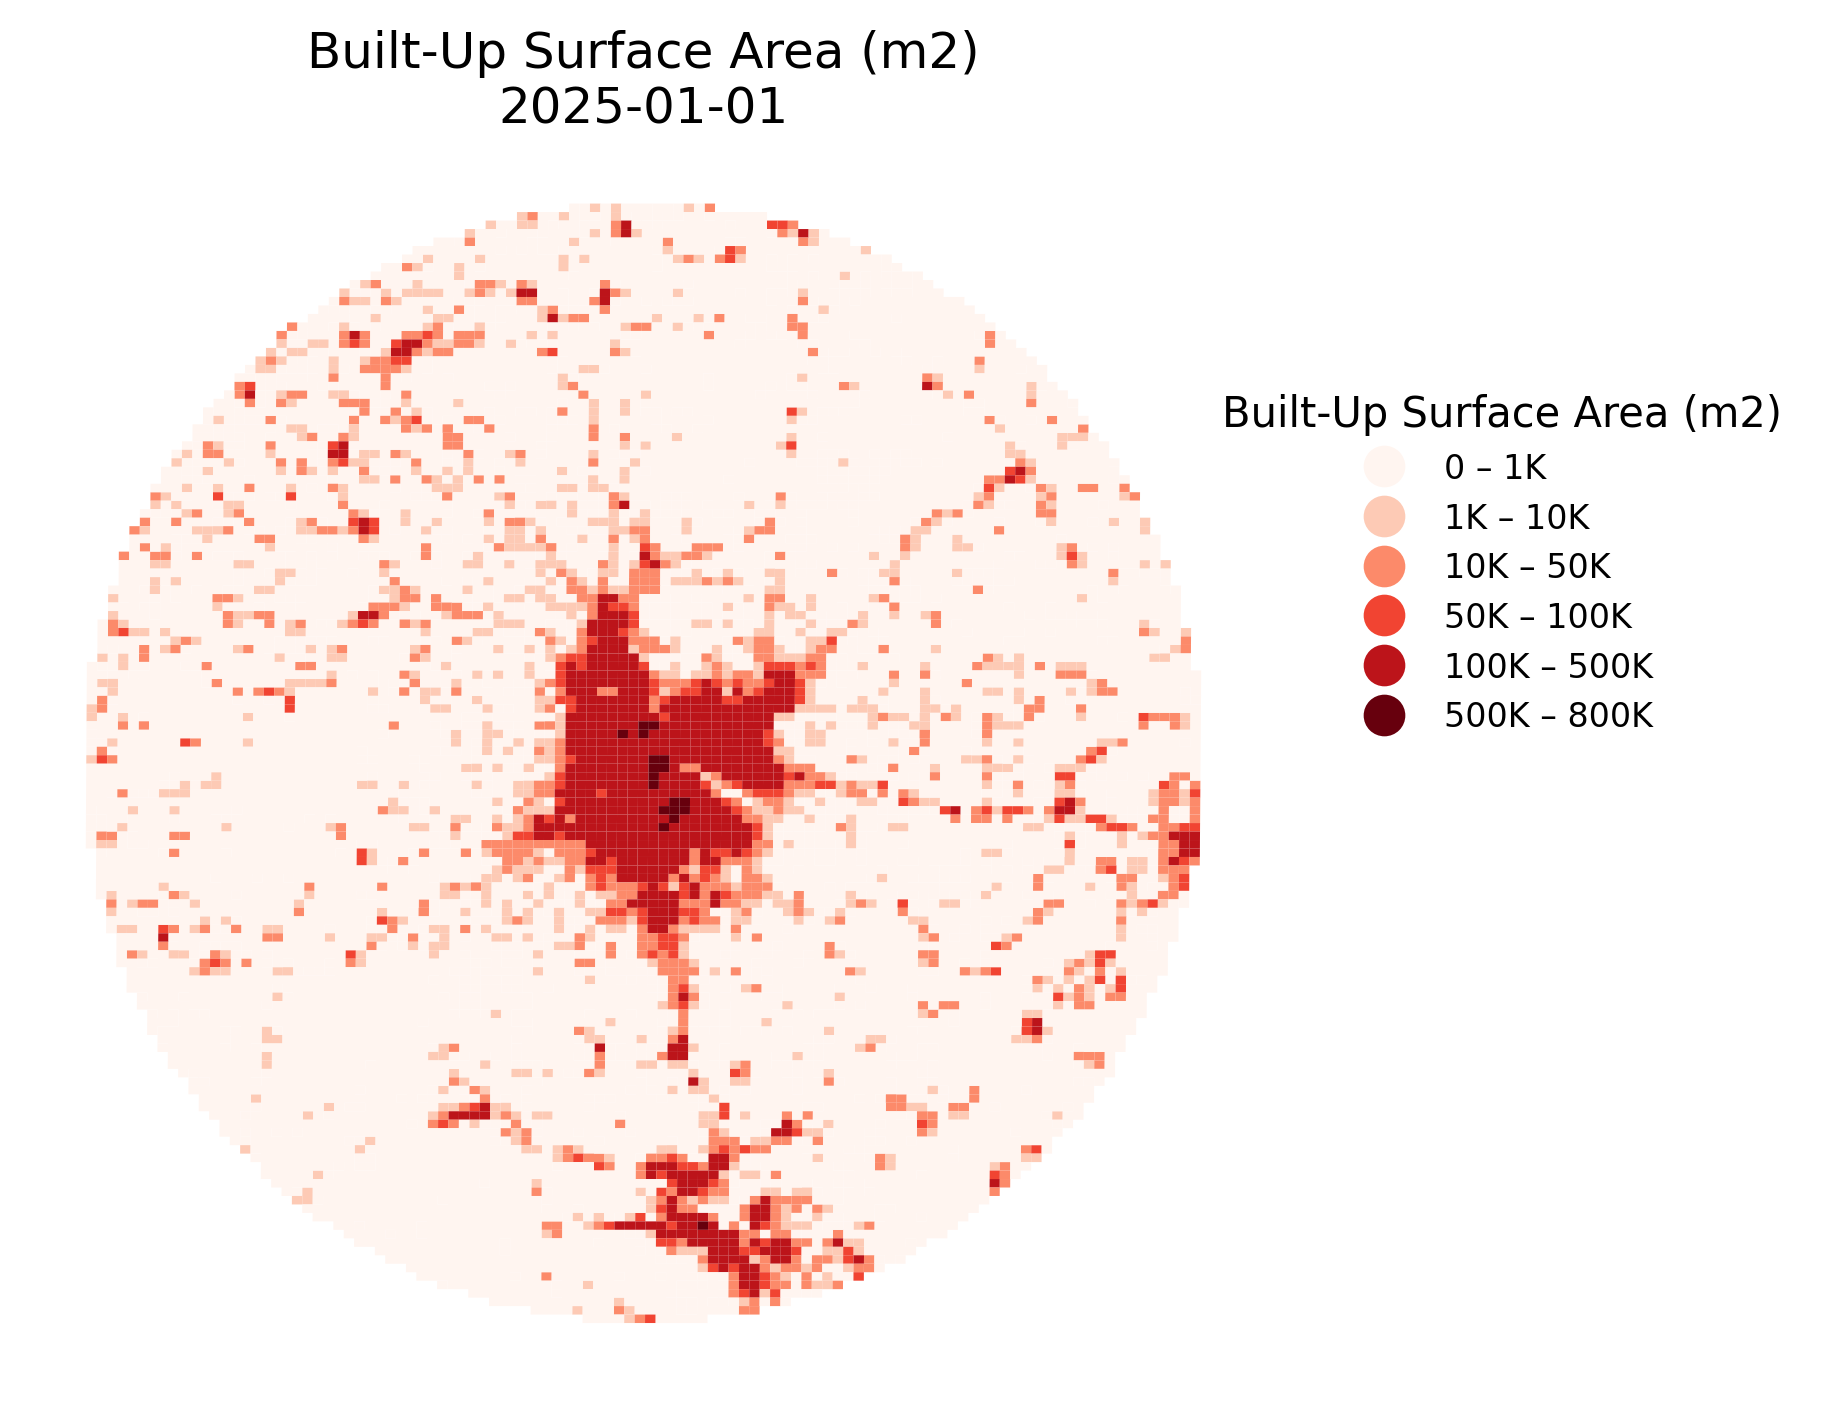

In [55]:
create_gif(
    data=data,
    variable='GHS_BUILT',
    scheme=built_scheme,
    fps=1.0,
    export_name="frames/ghs_built.gif",
    #extent=extent
)